In [1]:

######## snakemake preamble start (automatically inserted, do not edit) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('output/03_model_biology/01_gtex/01_LV_importance_rf_true_labels/gtex_feature_importance_true_labels_binary_shap', 'output/01_model_building/01_gtex/CLAMPfull.rds', 'output/01_model_building/01_gtex/CLAMPfull/Z.csv', 'data/gtex/GTEx_Analysis_v8_xCell_scores_7_celltypes.txt', 'data/pathways/Cell_marker_Human.xlsx', '/home/msubirana/Documents/pivlab/clamp-analyses/nbs/03_model_biology/01_gtex/06_multitissue_xcell_recovery.ipynb', "shap_dir" = 'output/03_model_biology/01_gtex/01_LV_importance_rf_true_labels/gtex_feature_importance_true_labels_binary_shap', "clamp_model" = 'output/01_model_building/01_gtex/CLAMPfull.rds', "z_matrix" = 'output/01_model_building/01_gtex/CLAMPfull/Z.csv', "xcell" = 'data/gtex/GTEx_Analysis_v8_xCell_scores_7_celltypes.txt', "cell_marker_file" = 'data/pathways/Cell_marker_Human.xlsx', "notebook" = '/home/msubirana/Documents/pivlab/clamp-analyses/nbs/03_model_biology/01_gtex/06_multitissue_xcell_recovery.ipynb'),
    output = list('output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_recovery_panel_ready.csv', 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_shap_by_model.csv', 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/cellmarker_ora_top1_per_lv.csv', 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_recovery_summary.csv', 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/notebook.complete', "panel_ready" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_recovery_panel_ready.csv', "shap_by_model" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_shap_by_model.csv', "ora_top1" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/cellmarker_ora_top1_per_lv.csv', "summary" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/multitissue_recovery_summary.csv', "complete" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery/notebook.complete'),
    params = list('output/03_model_biology/01_gtex/06_multitissue_xcell_recovery', "out_dir" = 'output/03_model_biology/01_gtex/06_multitissue_xcell_recovery'),
    wildcards = list(),
    threads = 1,
    log = list('/home/msubirana/Documents/pivlab/clamp-analyses/nbs/03_model_biology/01_gtex/06_multitissue_xcell_recovery.executed.ipynb', "notebook" = '/home/msubirana/Documents/pivlab/clamp-analyses/nbs/03_model_biology/01_gtex/06_multitissue_xcell_recovery.executed.ipynb'),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("datasets" = list("Brain_Mathys2023" = list("build_pseudobulk" = FALSE, "pseudobulk_dir" = 'data/pseudobulk/Brain_Mathys2023', "kind" = 'matrix_market', "raw" = 'data/pseudobulk/raw/Brain_Mathys2023/ad430_matrix.mtx.gz', "features" = 'data/pseudobulk/raw/Brain_Mathys2023/ad430_features.tsv.gz', "barcodes" = 'data/pseudobulk/raw/Brain_Mathys2023/ad430_barcodes.tsv.gz', "metadata" = 'data/pseudobulk/raw/Brain_Mathys2023/meta.tsv', "cell_id_col" = 'cellName', "sample_col" = 'Individual', "sample_transform" = 'identity', "truth_v0_col" = 'Major_Cell_Type', "truth_v1_col" = 'Cell_Type', "raw_cell_type_col" = 'Major_Cell_Type', "projection_label_col" = 'Major_Cell_Type', "cohort_manifest" = 'data/pseudobulk/Brain_Mathys2023/patient_info.csv'), "Brain_Xiong2023" = list("build_pseudobulk" = FALSE, "pseudobulk_dir" = 'data/pseudobulk/Brain_Xiong2023', "kind" = 'matrix_market', "raw" = 'data/pseudobulk/raw/Brain_Xiong2023/matrix.mtx.gz', "features" = 'data/pseudobulk/raw/Brain_Xiong2023/features.tsv.gz', "barcodes" = 'data/pseudobulk/raw/Brain_Xiong2023/barcodes.tsv.gz', "metadata" = 'data/pseudobulk/raw/Brain_Xiong2023/meta.tsv', "cell_id_col" = 'cellId', "sample_col" = 'Individual', "sample_transform" = 'hyphen_to_underscore', "truth_v0_col" = 'Celltype', "truth_v1_col" = 'Subcelltype', "raw_cell_type_col" = 'Celltype', "projection_label_col" = 'Celltype', "cohort_manifest" = 'data/pseudobulk/Brain_Xiong2023/patient_info.csv'), "Heart_Datar2026" = list("build_pseudobulk" = TRUE, "kind" = 'h5ad', "raw" = 'data/pseudobulk/Heart_Datar2026/HeartMap_V1.0_raw_counts.h5ad', "matrix" = 'X', "sample_col" = 'donor_id', "sample_transform" = 'identity', "truth_v0_col" = 'cell_type__ontology_label', "raw_cell_type_col" = 'cell_type__ontology_label', "projection_label_col" = 'cell_type__ontology_label', "min_cells" = 400, "exclude" = list("cell_type__ontology_label" = c('cell')), "truth_v0_map" = list("adipocyte" = 'Adipocyte', "regular atrial cardiac myocyte" = 'AtrialCM', "endocardial cell" = 'Endocardial', "cardiac endothelial cell" = 'Endothelial', "mesothelial cell of epicardium" = 'Epicardial', "fibroblast of cardiac tissue" = 'Fibroblast', "endothelial cell of lymphatic vessel" = 'LymphaticEndothelial', "lymphocyte" = 'Lymphocyte', "macrophage" = 'Macrophage', "mast cell" = 'Mast', "cardiac neuron" = 'Neuronal', "pericyte" = 'Pericyte', "vascular associated smooth muscle cell" = 'VSMC', "regular ventricular cardiac myocyte" = 'VentricularCM'), "projection_label_map" = list("adipocyte" = 'Adipocyte', "regular atrial cardiac myocyte" = 'AtrialCM', "endocardial cell" = 'Endocardial', "cardiac endothelial cell" = 'Endothelial', "mesothelial cell of epicardium" = 'Epicardial', "fibroblast of cardiac tissue" = 'Fibroblast', "endothelial cell of lymphatic vessel" = 'LymphaticEndothelial', "lymphocyte" = 'Lymphocyte', "macrophage" = 'Macrophage', "mast cell" = 'Mast', "cardiac neuron" = 'Neuronal', "pericyte" = 'Pericyte', "vascular associated smooth muscle cell" = 'VSMC', "regular ventricular cardiac myocyte" = 'VentricularCM')), "PBMC_1k1k" = list("build_pseudobulk" = FALSE, "pseudobulk_dir" = 'data/pseudobulk/PBMC_1k1k', "kind" = 'h5ad', "raw" = 'data/pseudobulk/raw/PBMC_1k1k/PBMC_1k1k_raw.h5ad', "matrix" = 'X', "sample_col" = 'donor_id', "sample_transform" = 'sample_prefix_hyphen_to_underscore', "truth_v0_col" = 'predicted.celltype.l2', "raw_cell_type_col" = 'predicted.celltype.l2', "projection_label_col" = 'predicted.celltype.l2', "cohort_manifest" = 'data/pseudobulk/PBMC_1k1k/patient_info.csv', "truth_v0_map" = list("CD4 CTL" = 'CD4_T', "CD4 Naive" = 'CD4_T', "CD4 Proliferating" = 'CD4_T', "CD4 TCM" = 'CD4_T', "CD4 TEM" = 'CD4_T', "Treg" = 'CD4_T', "CD8 Naive" = 'CD8_T', "CD8 Proliferating" = 'CD8_T', "CD8 TCM" = 'CD8_T', "CD8 TEM" = 'CD8_T', "gdT" = 'gd_T', "B intermediate" = 'B_cell', "B memory" = 'B_cell', "B naive" = 'B_cell', "Plasmablast" = 'Plasma_B', "CD14 Mono" = 'CD14_Mono', "CD16 Mono" = 'CD16_Mono', "cDC1" = 'DC', "cDC2" = 'DC', "ASDC" = 'DC', "NK" = 'NK', "NK Proliferating" = 'NK', "NK_CD56bright" = 'NK'), "projection_label_map" = list("CD4 CTL" = 'CD4_T', "CD4 Naive" = 'CD4_T', "CD4 Proliferating" = 'CD4_T', "CD4 TCM" = 'CD4_T', "CD4 TEM" = 'CD4_T', "Treg" = 'CD4_T', "CD8 Naive" = 'CD8_T', "CD8 Proliferating" = 'CD8_T', "CD8 TCM" = 'CD8_T', "CD8 TEM" = 'CD8_T', "gdT" = 'gd_T', "B intermediate" = 'B_cell', "B memory" = 'B_cell', "B naive" = 'B_cell', "Plasmablast" = 'Plasma_B', "CD14 Mono" = 'CD14_Mono', "CD16 Mono" = 'CD16_Mono', "cDC1" = 'DC', "cDC2" = 'DC', "ASDC" = 'DC', "NK" = 'NK', "NK Proliferating" = 'NK', "NK_CD56bright" = 'NK')), "PBMC_Perez2022" = list("build_pseudobulk" = FALSE, "pseudobulk_dir" = 'data/pseudobulk/PBMC_Perez2022', "kind" = 'h5ad', "raw" = 'data/pseudobulk/raw/PBMC_Perez2022/PBMC_Perez2022_raw.h5ad', "matrix" = 'raw.X', "sample_col" = 'ind_cov', "sample_transform" = 'sample_prefix_hyphen_to_underscore', "truth_v0_col" = 'cell_type', "raw_cell_type_col" = 'cell_type', "projection_label_col" = 'cell_type', "cohort_manifest" = 'data/pseudobulk/PBMC_Perez2022/patient_info.csv', "truth_v0_map" = list("B cell" = 'B_cell', "plasmablast" = 'B_cell', "classical monocyte" = 'Myeloid', "non-classical monocyte" = 'Myeloid', "conventional dendritic cell" = 'Myeloid', "plasmacytoid dendritic cell" = 'Myeloid', "progenitor cell" = 'Myeloid', "natural killer cell" = 'NK', "CD4-positive, alpha-beta T cell" = 'T_cell', "CD8-positive, alpha-beta T cell" = 'T_cell', "lymphocyte" = 'T_cell'), "projection_label_map" = list("B cell" = 'B_cell', "plasmablast" = 'B_cell', "classical monocyte" = 'Myeloid', "non-classical monocyte" = 'Myeloid', "conventional dendritic cell" = 'Myeloid', "plasmacytoid dendritic cell" = 'Myeloid', "progenitor cell" = 'Myeloid', "natural killer cell" = 'NK', "CD4-positive, alpha-beta T cell" = 'T_cell', "CD8-positive, alpha-beta T cell" = 'T_cell', "lymphocyte" = 'T_cell')), "Lung_Sikkema2023" = list("build_pseudobulk" = TRUE, "kind" = 'h5ad', "raw" = 'data/pseudobulk/Lung_Sikkema2023/lung_HLCA.h5ad', "matrix" = 'raw.X', "sample_col" = 'donor_id', "sample_transform" = 'identity', "truth_v0_col" = 'ann_level_2', "truth_v1_col" = 'ann_finest_level', "raw_cell_type_col" = 'ann_level_3', "projection_label_col" = 'ann_level_2', "min_cells" = 400)), "methods" = list("CLAMPbase" = 'CLAMPbase/B.csv', "CLAMPfull" = 'CLAMPfull/B.csv', "PLIER" = 'PLIER/B.csv', "PCA" = 'PCA/B.csv', "NMF" = 'NMF/B.csv', "ICA" = 'ICA/B.csv', "Flashier" = 'flashier/B.csv', "MOFA-FLEX" = 'MOFA_FLEX_PRIOR/B.csv', "GSSig" = 'GSS/B.csv', "CoGAPS" = 'CoGAPS/B.csv'), "paths" = list("production" = 'output/01_model_building/00_pseudobulk', "biology" = 'output/03_model_biology/00_pseudobulk', "model_notebooks" = 'nbs/01_model_building/00_pseudobulk', "biology_notebooks" = 'nbs/03_model_biology/00_pseudobulk', "panels" = 'output/99_panels', "panels_notebooks" = 'nbs/99_panels'), "references" = list("go_bp_url" = 'https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2025', "go_bp_file" = 'output/01_model_building/00_pseudobulk/references/GO_Biological_Process_2025.gmt', "go_bp_sha256" = '0fc02458765cfce6c9348dce9f7a9397c6caf7c09ba318f468135d7ac60342ee', "cell_marker_file" = 'data/pathways/Cell_marker_Human.xlsx', "allen_brain_gmt_file" = 'data/pathways/Allen_Brain_Atlas_10x_scRNA_2021.gmt', "azimuth_file" = 'data/pathways/Azimuth_2023.txt', "gtex_tissues_pathmat" = 'data/archs4/GTEx_Tissues_pathMat.rds', "brain_datasets" = c('Brain_Mathys2023', 'Brain_Xiong2023')), "preprocess" = list("mean_cutoff" = 0.5, "var_cutoff" = 0.1, "seed" = 123), "clamp" = list("max_iter" = 500, "seed" = 123), "grouped_cv" = list("n_folds" = 5, "group_col" = 'sample', "split_seed" = 42, "min_train_lv_cor" = 0.5, "bootstrap_seed" = 123, "bootstrap_replicates" = 10000), "flashier" = list("backfit_maxiter" = 10), "cogaps" = list("n_iterations" = 5000, "n_threads" = 4, "seed" = 123), "mofa_flex" = list("max_epochs" = 200, "seed" = 123), "projection" = list("chunk_cells" = 20000, "chunk_nnz" = 20000000, "top_fraction" = 0.01), "gtex" = list("raw_url" = 'https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz', "raw_gz" = 'data/gtex/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz', "metadata" = 'data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt', "xcell_scores" = 'data/gtex/GTEx_Analysis_v8_xCell_scores_7_celltypes.txt', "paths" = list("production" = 'output/01_model_building/01_gtex', "biology" = 'output/03_model_biology/01_gtex', "model_notebooks" = 'nbs/01_model_building/01_gtex', "biology_notebooks" = 'nbs/03_model_biology/01_gtex'), "raw_data" = list("chunk_size" = 100, "n_cores" = 1), "preprocess" = list("mean_cutoff" = 0.5, "var_cutoff" = 0.1, "seed" = 123), "clamp" = list("max_iter" = 500, "seed" = 123), "flashier" = list("backfit_maxiter" = 20), "mofa_flex_prior" = list("msigdb_category" = 'c5.go.bp', "msigdb_dbver" = '2026.1.Hs', "min_fraction" = 0.4, "min_count" = 40, "max_count" = 200, "similarity_threshold" = 0.8, "max_epochs" = 1000, "seed" = 123), "cogaps" = list("n_iterations" = 5000, "n_threads" = 4, "seed" = 123, "timeout_days" = 7), "gss" = list("d_cluster" = 4, "seed" = 123), "kmeans_clustering" = list("min_samples" = 50, "ari_min_samples" = 1, "base_seed" = 10000, "n_reps_per_k" = 50, "gene_fractions" = c(1.0, 0.75, 0.5, 0.25, 0.1, 0.05, 0.01)), "lv_importance" = list("global_seed" = 42, "min_rf_accuracy" = 0.9), "subtissue_inference" = list("n_folds" = 5, "global_seed" = 42, "min_rf_accuracy" = 0.85, "min_subtissue_samples" = 20, "n_jobs_per_fold" = 8, "anatomical_spec" = 'workflow/config/gtex_anatomical_subtissues.tsv', "permutation_repeats" = 1000, "bootstrap_repeats" = 1000, "evaluation_jobs" = 8, "tissues" = c('Adipose Tissue', 'Blood', 'Blood Vessel', 'Brain', 'Colon', 'Esophagus', 'Heart', 'Kidney', 'Skin'))), "runtime_benchmark" = list("seeds" = c(123, 456, 789), "threads" = 4, "methods" = c('CLAMPfull', 'CLAMPbase', 'PLIER', 'CoGAPS', 'Flashier', 'NMF', 'PCA', 'ICA', 'GSSig', 'MOFA-FLEX'), "output_root" = 'output/02_model_performance/00_pseudobulk/00_computational_timing', "notebook" = 'nbs/02_model_performance/00_pseudobulk/00_computational_timing.ipynb')),
    rule = 'multitissue_xcell_recovery_gtex',
    bench_iteration = as.numeric(NA),
    scriptdir = '/home/msubirana/Documents/pivlab/clamp-analyses/nbs/03_model_biology/01_gtex',
    source = function(...){
        wd <- getwd()
        setwd(snakemake@scriptdir)
        source(...)
        setwd(wd)
    }
)
setwd('/home/msubirana/Documents/pivlab/clamp-analyses');

######## snakemake preamble end #########


# Multi-tissue cell-type recovery from xCell

Generalises `05_liver_disentangle_xcell.ipynb` from one tissue to five, so the claim
is tested against every xCell cell type at once rather than hepatocytes alone.

For each of five GTEx tissues we take the latent variables carrying the top 20% of
that tissue's classifier SHAP importance, then ask two independent questions of each:

- **What do its genes say?** CellMarker over-representation of the LV's top 1% of
  genes by loading. This uses only the Z matrix.
- **What do its samples say?** The mean xCell score of every cell type in the 1% of
  GTEx samples where the LV is most active. This uses only the B matrix.

The two draw on disjoint parts of the model, so agreement between them is evidence
rather than circularity.

Each cell type column is backed by one tissue model, which lets the dots be coloured
by a SHAP contrast: how much more important this LV is to its own tissue's classifier
than to the others. Whole Blood and Skin back the neutrophil and keratinocyte columns
so no column is left uncoloured, even though neither tissue contributes rows.

No model is fitted or altered here.

💡 **Environment:** `clamp-analyses`

## Libraries

In [2]:
suppressPackageStartupMessages({
  library(here); library(data.table); library(readxl)
})

## Settings

`SPEC` pairs one GTEx tissue with each xCell cell type so every cell type appears on
both axes and the block diagonal is complete. Row order sets the diagonal.

In [3]:
OUT_DIR <- here(snakemake@params[["out_dir"]])
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

TOP_SAMPLE_PCT <- 0.01   # top-1% samples per LV, as in 05_liver_disentangle_xcell
TOP_GENE_PCT   <- 0.01   # matches get_top_genes() elsewhere in the project
CUM_THR        <- 20     # cumulative % of a tissue's SHAP mass
MIN_GS <- 10; MAX_GS <- 500
SHAP_EPS <- 1e-3

SPEC <- data.table(
  tissue   = c("Esophagus - Mucosa", "Liver", "Brain - Cortex",
               "Muscle - Skeletal", "Adipose - Visceral (Omentum)"),
  expected = c("Epithelial_cells", "Hepatocytes", "Neurons",
               "Myocytes", "Adipocytes"),
  short    = c("Esophagus Mucosa", "Liver", "Brain Cortex",
               "Muscle Skeletal", "Adipose Visceral"))

# Skin and Whole Blood contribute no rows: all three of Skin's cum-20% LVs are
# Epithelial-dominant because xCell's keratinocyte and epithelial signatures are
# correlated, and none of Whole Blood's LVs recovers a neutrophil term by ORA.
# Their models still back the two remaining columns so the grid has no grey cells.
# Chosen by the mean xCell score of that cell type in the top-1% samples of each
# candidate's own cum-20% LVs: Whole Blood 0.273 vs Spleen 0.118 for neutrophils,
# Skin - Sun Exposed 0.220 vs Not Sun Exposed 0.147 for keratinocytes.
EXTRA <- data.table(
  tissue   = c("Whole Blood", "Skin - Sun Exposed (Lower leg)"),
  expected = c("Neutrophils", "Keratinocytes"),
  short    = c("Whole Blood", "Skin Sun Exposed"))

MODELS    <- c(SPEC$tissue, EXTRA$tissue)
CT_ORDER  <- c(SPEC$expected, EXTRA$expected)
CT_LABELS <- c("Epithelial", "Hepatocytes", "Neurons", "Myocytes", "Adipocytes",
               "Neutrophils", "Keratinocytes")

## Inputs

In [4]:
shap <- as.data.table(read.table(
  file.path(snakemake@input[["shap_dir"]], "all_shap_positive.tsv"),
  sep = "\t", header = TRUE))

xcell <- as.matrix(read.table(snakemake@input[["xcell"]], sep = "\t",
                              header = TRUE, row.names = 1, check.names = FALSE))
stopifnot(setequal(rownames(xcell), CT_ORDER))

model <- readRDS(snakemake@input[["clamp_model"]])
B <- as.matrix(model$B)                       # LVs x samples
colnames(B) <- gsub("\\.", "-", colnames(B))  # readRDS mangles GTEX-XXXX-YYYY
common <- intersect(colnames(B), colnames(xcell))
B <- B[, common]; xcell <- xcell[, common]
n_top_samples <- max(1L, ceiling(length(common) * TOP_SAMPLE_PCT))

Z <- fread(snakemake@input[["z_matrix"]])
genes_all <- Z[[1]]
LV_COLS <- setdiff(names(Z), names(Z)[1])

cat(sprintf("SHAP %d rows | xCell %d cell types x %d shared samples (top 1%% = %d)\n",
            nrow(shap), nrow(xcell), length(common), n_top_samples))
cat(sprintf("Z: %d genes x %d LVs\n", nrow(Z), length(LV_COLS)))

SHAP 23559 rows | xCell 7 cell types x 17382 shared samples (top 1% = 174)


Z: 21613 genes x 578 LVs


## LV selection: cumulative 20% of each tissue's SHAP mass

Ranking by SHAP and cutting at a cumulative share, rather than a fixed top-N, lets
each tissue contribute as many LVs as its importance is actually spread over.

In [5]:
shap_pct <- copy(shap)[Tissue %in% MODELS]
shap_pct[, pct := Mean_SHAP_Tissue / sum(Mean_SHAP_Tissue) * 100, by = Tissue]

lv_ord <- rbindlist(lapply(seq_len(nrow(SPEC)), function(i) {
  s <- shap_pct[Tissue == SPEC$tissue[i]][order(-pct)]
  s[, cum := cumsum(pct)]
  # Include the LV that crosses the threshold, not just those below it: the set
  # has to reach 20% to be "the LVs carrying the top 20%". Stopping at cum <= 20
  # drops one LV from every tissue.
  n <- which(s$cum >= CUM_THR)[1]
  if (is.na(n)) n <- nrow(s)
  keep <- s[seq_len(n)]
  data.table(tissue = SPEC$tissue[i], short = SPEC$short[i],
             expected = SPEC$expected[i], LV = keep$Feature,
             shap_pct = keep$pct, rank = seq_len(nrow(keep)))
}))
setorder(lv_ord, tissue, rank)
cat(sprintf("%d LVs at cumulative %d%%:\n", nrow(lv_ord), CUM_THR))
print(as.data.frame(lv_ord[, .(n_LVs = .N, shap_range = sprintf("%.2f-%.2f%%",
      min(shap_pct), max(shap_pct))), by = .(tissue, expected)]), row.names = FALSE)

16 LVs at cumulative 20%:


                       tissue         expected n_LVs  shap_range
 Adipose - Visceral (Omentum)       Adipocytes     4  3.73-9.25%
               Brain - Cortex          Neurons     3 4.10-10.28%
           Esophagus - Mucosa Epithelial_cells     3 5.80-12.68%
                        Liver      Hepatocytes     3  7.87-8.90%
            Muscle - Skeletal         Myocytes     3  6.01-7.97%


## What the samples say: xCell scores in each LV's top-1% samples

In [6]:
d <- rbindlist(lapply(seq_len(nrow(lv_ord)), function(i) {
  lv  <- lv_ord$LV[i]
  top <- order(B[lv, ], decreasing = TRUE)[seq_len(n_top_samples)]
  data.table(tissue = lv_ord$tissue[i], short = lv_ord$short[i],
             expected = lv_ord$expected[i], LV = lv,
             shap_pct = lv_ord$shap_pct[i], rank = lv_ord$rank[i],
             cell_type_key = rownames(xcell),
             top1pct = rowMeans(xcell[, top, drop = FALSE]),
             background = rowMeans(xcell[, -top, drop = FALSE]))
}))
d[, l2fc_vs_background := log2((pmax(top1pct, 0) + 1e-4) /
                               (pmax(background, 0) + 1e-4))]

# Dominant cell type per LV: the box drawn on the grid.
d[, dominant := cell_type_key[which.max(top1pct)], by = .(tissue, LV)]
lv_ord[, dominant := d[.SD, on = .(tissue, LV), mult = "first", x.dominant]]
lv_ord[, hit := dominant == expected]

cat(sprintf("\nOverall: %d / %d LVs dominated by their tissue's expected cell type (%.0f%%)\n",
            sum(lv_ord$hit), nrow(lv_ord), 100 * mean(lv_ord$hit)))
print(as.data.frame(lv_ord[, .(n_LVs = .N, recovered = sprintf("%d/%d", sum(hit), .N)),
                           by = .(tissue, expected)]), row.names = FALSE)


Overall: 14 / 16 LVs dominated by their tissue's expected cell type (88%)


                       tissue         expected n_LVs recovered
 Adipose - Visceral (Omentum)       Adipocytes     4       3/4
               Brain - Cortex          Neurons     3       3/3
           Esophagus - Mucosa Epithelial_cells     3       3/3
                        Liver      Hepatocytes     3       3/3
            Muscle - Skeletal         Myocytes     3       2/3


## The SHAP contrast that colours the dots

Each cell-type column maps to its tissue model, so a dot's fill can say how much more
important that LV is to the matching tissue's classifier than to the others:

$$\log_2 \frac{\text{SHAP\%}[LV, T] + \epsilon}{\text{mean SHAP\% of the same LV over the other 6 tissues} + \epsilon}$$

The leave-one-out denominator is deliberate. Dividing by the LV's mean across *all*
seven models caps the diagonal at $\log_2 7$ and squashes every own-tissue cell into a
narrow band; leaving the own tissue out of its own reference does not.

In [7]:
n_mod <- length(MODELS)
shap_grid <- CJ(LV = lv_ord$LV, model = MODELS, unique = TRUE)
shap_grid[, shap_pct := shap_pct[.SD, on = .(Feature = LV, Tissue = model), x.pct]]
# all_shap_positive.tsv lists only positive-SHAP LVs, so an absent pair is a
# genuine zero rather than missing data.
shap_grid[is.na(shap_pct), shap_pct := 0]
shap_grid <- merge(shap_grid, unique(lv_ord[, .(LV, tissue)]), by = "LV")
shap_grid[, is_own := model == tissue]
shap_grid[, l2fc_shap := log2((shap_pct + SHAP_EPS) /
                              ((sum(shap_pct) - shap_pct) / (n_mod - 1) + SHAP_EPS)),
          by = LV]

# The block diagonal's claim, checked over the five ROW tissues only. Whole Blood
# and Skin are column-only models and are allowed to outrank a row tissue.
own_max <- shap_grid[model %in% SPEC$tissue,
                     .(ok = shap_pct[is_own] == max(shap_pct)), by = LV]
if (any(!own_max$ok))
  stop("Own tissue is not the SHAP maximum among the row tissues for: ",
       paste(own_max[ok == FALSE, LV], collapse = ", "))

# A column-only model beating a row tissue is a real result, not an error: LV546 is
# a squamous programme that skin weights more heavily than esophageal mucosa.
cross <- shap_grid[, {
  e <- model %in% EXTRA$tissue
  .(own = shap_pct[is_own], best_extra = max(shap_pct[e]),
    which_extra = model[e][which.max(shap_pct[e])])
}, by = .(LV, tissue)][best_extra > own]
cat("=== LVs where a column-only model outranks the LV's own tissue ===\n")
if (nrow(cross)) print(as.data.frame(cross), row.names = FALSE) else cat("none\n")

cat(sprintf("\nown-cell log2FC %.2f to %.2f | off-cell %.2f to %.2f | %.0f%% of off cells negative\n",
    min(shap_grid[is_own == TRUE, l2fc_shap]), max(shap_grid[is_own == TRUE, l2fc_shap]),
    min(shap_grid[is_own == FALSE, l2fc_shap]), max(shap_grid[is_own == FALSE, l2fc_shap]),
    100 * mean(shap_grid[is_own == FALSE, l2fc_shap] < 0)))

CT2TISSUE <- setNames(MODELS, CT_ORDER)
d[, model_tissue := CT2TISSUE[cell_type_key]]
d <- merge(d, shap_grid[, .(LV, model, l2fc_shap)],
           by.x = c("LV", "model_tissue"), by.y = c("LV", "model"), all.x = TRUE)
stopifnot(!any(is.na(d$l2fc_shap)))

=== LVs where a column-only model outranks the LV's own tissue ===


    LV             tissue      own best_extra                    which_extra
 LV546 Esophagus - Mucosa 5.795464   12.36509 Skin - Sun Exposed (Lower leg)



own-cell log2FC 0.79 to 6.28 | off-cell -11.13 to 2.46 | 89% of off cells negative


## What the genes say: CellMarker ORA of each LV's top-1% genes

Hypergeometric test against CellMarker human cell-type sets, BH-corrected within each
LV, reported as fold enrichment and gene overlap so it draws as a standard ORA plot.
The universe is restricted to model genes CellMarker can annotate at all; using every
gene in Z would inflate fold enrichment for every term.

In [8]:
cm <- as.data.table(read_excel(snakemake@input[["cell_marker_file"]], sheet = "human"))
cm <- cm[!is.na(Symbol) & !is.na(cell_name) & species == "Human"]
sets <- lapply(split(cm$Symbol, cm$cell_name), unique)
sets <- sets[lengths(sets) >= MIN_GS & lengths(sets) <= MAX_GS]

universe <- intersect(genes_all, unique(unlist(sets)))
sets <- lapply(sets, function(g) intersect(g, universe))
sets <- sets[lengths(sets) >= MIN_GS]
N <- length(universe)
n_top_genes <- max(1L, ceiling(nrow(Z) * TOP_GENE_PCT))
cat(sprintf("ORA: %d sets, universe %d genes, top %d genes per LV\n",
            length(sets), N, n_top_genes))

ora_lv <- function(lv) {
  ord <- order(Z[[lv]], decreasing = TRUE)[seq_len(n_top_genes)]
  top <- intersect(genes_all[ord], universe)
  if (length(top) < 5) return(NULL)
  n <- length(top)
  rbindlist(lapply(names(sets), function(term) {
    K <- length(sets[[term]]); k <- length(intersect(top, sets[[term]]))
    data.table(LV = lv, term = term, Genes = k, set_size = K,
               n_top_in_universe = n, universe = N,
               FoldEnriched = (k / n) / (K / N),
               pvalue = phyper(k - 1L, K, N - K, n, lower.tail = FALSE))
  }))[Genes > 0]
}

ora <- rbindlist(lapply(unique(lv_ord$LV), ora_lv))
ora[, FDR := p.adjust(pvalue, method = "BH"), by = LV]   # each LV its own family
ora[, EnrichmentFDR := -log10(pmax(FDR, 1e-300))]

# Project convention (02_disentangle.ipynb): filter FDR < 0.05, then rank 1 by
# ascending FDR. Fold enrichment only breaks ties -- ranking by fold enrichment
# instead promotes tiny sets and named a brain LV "Beta cell".
ora_top1 <- ora[FDR < 0.05][order(FDR, -FoldEnriched), .SD[1L], by = LV]
missing <- setdiff(unique(lv_ord$LV), ora_top1$LV)
if (length(missing))
  ora_top1 <- rbind(ora_top1, data.table(LV = missing), fill = TRUE)
setorder(ora_top1, LV)
cat(sprintf("%d/%d LVs have a significant CellMarker term\n",
            sum(!is.na(ora_top1$term)), nrow(ora_top1)))

ORA: 289 sets, universe 7079 genes, top 217 genes per LV


15/16 LVs have a significant CellMarker term


## Assemble the panel-ready table

In [9]:
d[, cell_type := factor(cell_type_key, levels = CT_ORDER, labels = CT_LABELS)]
d[, dominant_label := factor(dominant, levels = CT_ORDER, labels = CT_LABELS)]
d[, is_dominant := cell_type == dominant_label]
stopifnot(sum(d$is_dominant) == uniqueN(d[, .(tissue, LV)]))

d[, tissue := factor(tissue, levels = SPEC$tissue)]
d[, short  := factor(short,  levels = SPEC$short)]
setorder(d, tissue, rank, cell_type)

panel_ready <- merge(
  d[, .(tissue, short, LV, shap_pct, rank, expected, dominant, dominant_label,
        cell_type, cell_type_key, is_dominant, top1pct, background,
        l2fc_vs_background, l2fc_shap)],
  ora_top1[, .(LV, ora_term = term, ora_genes = Genes, ora_set_size = set_size,
               ora_fold = FoldEnriched, ora_fdr = FDR,
               ora_neg_log10_fdr = EnrichmentFDR)],
  by = "LV", all.x = TRUE)
setorder(panel_ready, tissue, rank, cell_type)

summary_tbl <- lv_ord[, .(n_LVs = .N, n_recovered = sum(hit),
                          recovered = sprintf("%d/%d", sum(hit), .N)),
                      by = .(tissue, expected)]
cat(sprintf("panel_ready: %d rows (%d LVs x %d cell types)\n",
            nrow(panel_ready), uniqueN(panel_ready$LV), length(CT_ORDER)))

panel_ready: 112 rows (16 LVs x 7 cell types)


## Figure preview

Left: the top CellMarker term per LV, positioned by fold enrichment, sized by
overlapping genes and coloured by significance. Right: every LV against all seven
xCell cell types, sized by the mean xCell score in the LV's top-1% samples and
coloured by the SHAP contrast. The box marks each LV's highest-scoring cell type, so
a box off the block diagonal is a visible miss.

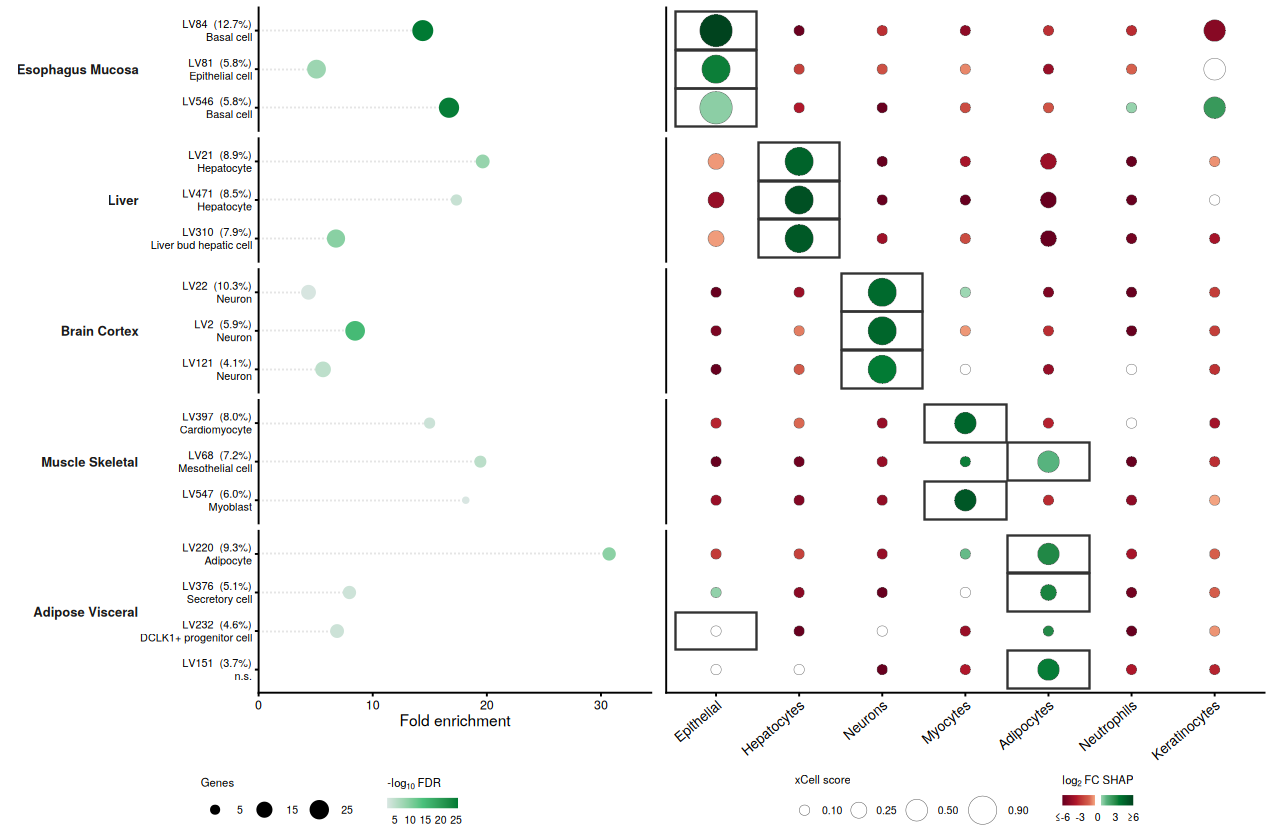

In [10]:
suppressPackageStartupMessages({ library(ggplot2); library(cowplot) })

cfg <- yaml::read_yaml(here("config.yaml"))
GREEN_PATHWAY <- unlist(cfg$GREEN_PATHWAY)

pr <- copy(panel_ready)
pr[, cell_type := factor(cell_type, levels = CT_LABELS)]
pr[, tissue := factor(tissue, levels = SPEC$tissue)]
pr[, short  := factor(short,  levels = SPEC$short)]

# Row order: tissue block, then descending SHAP within tissue. Two-line labels keep
# the LV identifiable while naming what the row is actually about.
lv_rows <- unique(pr[, .(tissue, short, LV, shap_pct, rank, ora_term, ora_fold,
                         ora_genes, ora_neg_log10_fdr)])
setorder(lv_rows, tissue, rank)
lv_rows[, term_clean := fifelse(is.na(ora_term) | !nzchar(ora_term), "n.s.",
                        fifelse(nchar(ora_term) > 34,
                                paste0(substr(ora_term, 1, 32), "\u2026"), ora_term))]
lv_rows[, key := paste(tissue, LV)]
ROW_LABELS <- rev(sprintf("%s  (%.1f%%)\n%s", lv_rows$LV, lv_rows$shap_pct,
                          lv_rows$term_clean))
lv_rows[, row_id := factor(key, levels = rev(key), labels = ROW_LABELS)]
pr[, row_id := factor(paste(tissue, LV), levels = rev(lv_rows$key), labels = ROW_LABELS)]

pA <- ggplot(lv_rows, aes(ora_fold, row_id)) +
  geom_segment(aes(x = 0, xend = ora_fold, yend = row_id), colour = "#cccccc",
               linewidth = 0.4, linetype = "dotted", na.rm = TRUE) +
  geom_point(aes(colour = ora_neg_log10_fdr, size = ora_genes), na.rm = TRUE) +
  facet_grid(short ~ ., scales = "free_y", space = "free_y", switch = "y") +
  scale_colour_gradientn(colours = GREEN_PATHWAY,
                         name = expression("-" * log[10] ~ "FDR"),
                         guide = guide_colourbar(title.position = "top", theme = theme(
                           legend.key.width = unit(1.5, "cm"),
                           legend.key.height = unit(0.22, "cm"),
                           legend.ticks = element_blank()))) +
  scale_size_continuous(range = c(1.2, 5), name = "Genes", breaks = c(5, 15, 25),
                        guide = guide_legend(title.position = "top")) +
  scale_x_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(x = "Fold enrichment", y = NULL) +
  theme_classic(base_size = 9) +
  theme(plot.background = element_rect(fill = "white", colour = NA),
        strip.placement = "outside", strip.background = element_blank(),
        strip.text.y.left = element_text(angle = 0, face = "bold", size = 7.5, hjust = 1),
        axis.text.y = element_text(size = 6.2, lineheight = 1.05),
        legend.position = "bottom", legend.box = "horizontal",
        legend.margin = margin(0, 6, 0, 6),
        legend.text = element_text(size = 6),
        legend.title = element_text(size = 6.5, hjust = 0))

# config.yaml's DIVERGING_VALUES hold white across 0.25-0.75, which over a +/-6
# domain renders log2FC = 3 as white. This ramp keeps the same red/green anchors but
# confines white to the +/-0.5 dead band, so anything past +/-0.5 shows colour.
FILL_VALS <- c(0, 0.20, 0.375, 0.4583, 0.4584, 0.5416, 0.5417, 0.625, 0.80, 1)
FILL_COLS <- c("#67001f", "#b2182b", "#d6604d", "#f4a582", "white", "white",
               "#a1d9b6", "#57b37e", "#007a33", "#00431e")

pB <- ggplot(pr, aes(cell_type, row_id)) +
  geom_tile(data = pr[is_dominant == TRUE], fill = NA, colour = "grey20",
            linewidth = 0.5, width = 0.98, height = 0.98) +
  geom_point(aes(size = top1pct, fill = l2fc_shap), shape = 21, stroke = 0.15,
             colour = "grey40") +
  facet_grid(short ~ ., scales = "free_y", space = "free_y") +
  # Binned, not continuous: xCell scores pile up near zero and a linear area
  # mapping renders every low dot as the same invisible speck, losing its colour.
  scale_size_binned(name = "xCell score", breaks = c(0.1, 0.25, 0.5, 0.9),
                    limits = c(0, max(pr$top1pct)), range = c(0.7, 9),
                    guide = guide_legend(title.position = "top",
                      override.aes = list(fill = "white", colour = "grey30"))) +
  scale_fill_gradientn(colours = FILL_COLS, values = FILL_VALS,
                       limits = c(-6, 6), oob = scales::squish,
                       breaks = c(-6, -3, 0, 3, 6),
                       labels = c("≤-6", "-3", "0", "3", "≥6"),
                       name = expression(log[2] ~ "FC SHAP"),
                       guide = guide_colourbar(title.position = "top", theme = theme(
                         legend.key.width = unit(1.5, "cm"),
                         legend.key.height = unit(0.22, "cm"),
                         legend.ticks = element_blank()))) +
  labs(x = NULL, y = NULL) +
  theme_classic(base_size = 9) +
  theme(plot.background = element_rect(fill = "white", colour = NA),
        axis.text.x = element_text(angle = 40, hjust = 1, size = 8),
        axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        strip.background = element_blank(), strip.text.y = element_blank(),
        legend.position = "bottom", legend.box = "horizontal",
        legend.text = element_text(size = 6),
        legend.title = element_text(size = 6.5, hjust = 0),
        legend.margin = margin(0, 6, 0, 6),
        legend.key.width = unit(0.42, "cm"), legend.key.height = unit(0.42, "cm"))

# Leaving each panel's legend attached puts the two rows at different heights,
# because panel B's rotated x labels are taller. Pulling all four guides into one
# strip lines them up.
legend_row <- cowplot::plot_grid(
  cowplot::get_plot_component(pA, "guide-box-bottom"),
  cowplot::get_plot_component(pB, "guide-box-bottom"),
  nrow = 1, rel_widths = c(1.45, 1.35))
body <- cowplot::plot_grid(pA + theme(legend.position = "none"),
                           pB + theme(legend.position = "none"),
                           nrow = 1, rel_widths = c(1.45, 1.35),
                           align = "h", axis = "tb")
panel_h <- 0.30 * nrow(lv_rows) + 1.6
fig <- cowplot::plot_grid(body, legend_row, ncol = 1,
                          rel_heights = c(panel_h, 0.55)) +
  theme(plot.background = element_rect(fill = "white", colour = NA))

options(repr.plot.width = 10.6, repr.plot.height = panel_h + 0.55)
fig

## Save

In [11]:
fwrite(panel_ready,  snakemake@output[["panel_ready"]])
fwrite(shap_grid,    snakemake@output[["shap_by_model"]])
fwrite(ora_top1,     snakemake@output[["ora_top1"]])
fwrite(summary_tbl,  snakemake@output[["summary"]])

cat("\nWrote:\n")
for (k in c("panel_ready", "shap_by_model", "ora_top1", "summary"))
  cat("  ", basename(snakemake@output[[k]]), "\n", sep = "")


Wrote:


  multitissue_recovery_panel_ready.csv
  multitissue_shap_by_model.csv
  cellmarker_ora_top1_per_lv.csv
  multitissue_recovery_summary.csv
